# Accuracy analysis of `conv()` and `@`

In [1]:
from itertools import product
import numpy as np

from triqs.gf import MeshReTime, MeshProduct, Gf

from tddt.retime import conv_ret_l, conv_l_adv, conv_ret_ret
from tddt.keldysh import KeldyshGF, from_lesser_greater, lesser, retarded_ext, advanced_ext, herm_conj, conv, Branch, ContourPoint

import matplotlib.pyplot as plt

Make Keldysh GF of a single fermion with energy `eps` and occupation number `n`

In [2]:
def make_g(eps, n, t_mesh):
    tt_mesh = MeshProduct(t_mesh, t_mesh)
    
    g_l = Gf(mesh=tt_mesh, target_shape=())
    g_g = Gf(mesh=tt_mesh, target_shape=())
    
    for t1, t2 in tt_mesh:
        g_g[t1, t2] = -1j * (1.0 - n) * np.exp(-1j * eps * (t1 - t2))
        g_l[t1, t2] = -1j * (-n) * np.exp(-1j * eps * (t1 - t2))
    
    return from_lesser_greater(g_l, g_g)

## Accuracy of real time convolution functions `conv_ret_l()`, `conv_l_adv()` and `conv_ret_ret()`

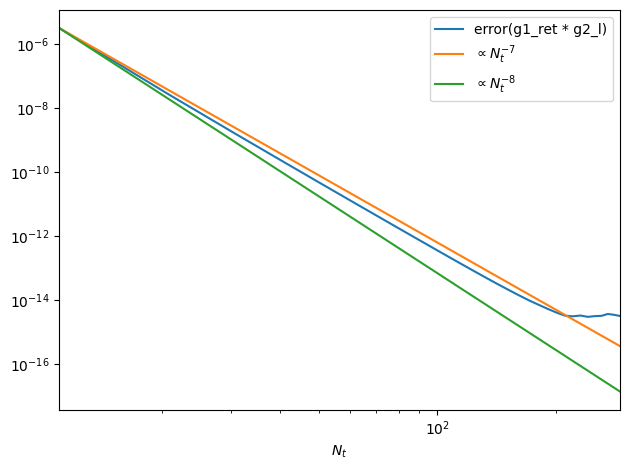

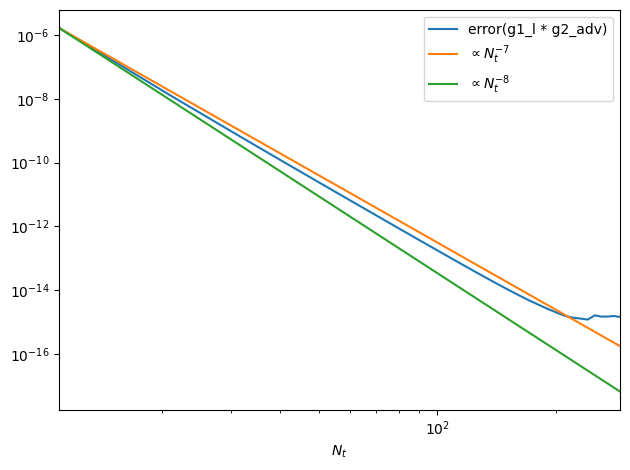

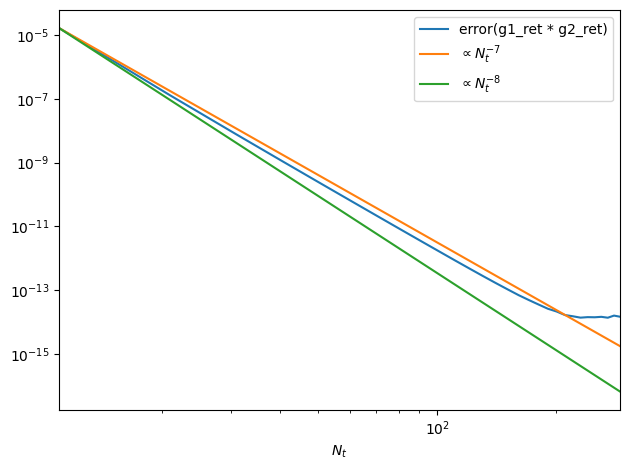

In [3]:
t_max = 10.0
N_t_range = range(11, 301, 10)

n1 = 0.1
n2 = 0.2
eps1 = 1.2
eps2 = 1.5

g1_ret_g2_l_error_list = []
g1_l_g2_adv_error_list = []
g1_ret_g2_ret_error_list = []

for N_t in N_t_range:
    t_mesh = MeshReTime(0.0, t_max, N_t)
    tt_mesh = MeshProduct(t_mesh, t_mesh)

    # Make G1 and G2
    G1 = make_g(eps1, n1, t_mesh)
    G2 = make_g(eps2, n2, t_mesh)

    g1_l = lesser(G1)
    g1_ret = retarded_ext(G1)
    g2_l = lesser(G2)
    g2_ret = retarded_ext(G2)
    g2_adv = advanced_ext(G2)

    g1_ret_g2_l = conv_ret_l(g1_ret, g2_l)
    g1_l_g2_adv = conv_l_adv(g1_l, g2_adv)
    g1_ret_g2_ret = conv_ret_ret(g1_ret, g2_ret)

    # Analytically computed reference values of the convolutions
    g1_ret_g2_l_ref = Gf(mesh=tt_mesh, target_shape=())
    g1_l_g2_adv_ref = Gf(mesh=tt_mesh, target_shape=())
    g1_ret_g2_ret_ref = Gf(mesh=tt_mesh, target_shape=())
    for t1, t2 in tt_mesh:
        g1_ret_g2_l_ref[t1, t2] = -1j * n2 / (eps1 - eps2) * (np.exp(-1j * eps2 * t1) - np.exp(-1j * eps1 * t1)) * np.exp(1j * eps2 * t2)
        g1_l_g2_adv_ref[t1, t2] = 1j * n1 / (eps1 - eps2) * np.exp(-1j * eps1 * t1) * (np.exp(1j * eps1 * t2) - np.exp(1j * eps2 * t2))
        if t1.linear_index >= t2.linear_index:
            g1_ret_g2_ret_ref[t1, t2] = -1j / (eps1 - eps2) * (np.exp(-1j * eps1 * (t1 - t2)) - np.exp(-1j * eps2 * (t1 - t2)))
    
    g1_ret_g2_l_error_list.append(np.max(np.abs((g1_ret_g2_l - g1_ret_g2_l_ref).data)))
    g1_l_g2_adv_error_list.append(np.max(np.abs((g1_l_g2_adv - g1_l_g2_adv_ref).data)))
    g1_ret_g2_ret_error_list.append(np.max(np.abs((g1_ret_g2_ret - g1_ret_g2_ret_ref).data)))

N_t_list = np.array(N_t_range, dtype=float)

plt.loglog(N_t_list, g1_ret_g2_l_error_list, label="error(g1_ret * g2_l)")
plt.loglog(N_t_list, (g1_ret_g2_l_error_list[0] / (N_t_list[0] ** (-7))) * N_t_list ** (-7), label="$\propto N_t^{-7}$")
plt.loglog(N_t_list, (g1_ret_g2_l_error_list[0] / (N_t_list[0] ** (-8))) * N_t_list ** (-8), label="$\propto N_t^{-8}$")
plt.xlim(N_t_list[0], N_t_list[-1])
plt.xlabel(r"$N_t$")
plt.legend()
plt.tight_layout()

plt.figure()
plt.loglog(N_t_list, g1_l_g2_adv_error_list, label="error(g1_l * g2_adv)")
plt.loglog(N_t_list, (g1_l_g2_adv_error_list[0] / (N_t_list[0] ** (-7))) * N_t_list ** (-7), label="$\propto N_t^{-7}$")
plt.loglog(N_t_list, (g1_l_g2_adv_error_list[0] / (N_t_list[0] ** (-8))) * N_t_list ** (-8), label="$\propto N_t^{-8}$")
plt.xlim(N_t_list[0], N_t_list[-1])
plt.xlabel(r"$N_t$")
plt.legend()
plt.tight_layout()

plt.figure()
plt.loglog(N_t_list, g1_ret_g2_ret_error_list, label="error(g1_ret * g2_ret)")
plt.loglog(N_t_list, (g1_ret_g2_ret_error_list[0] / (N_t_list[0] ** (-7))) * N_t_list ** (-7), label="$\propto N_t^{-7}$")
plt.loglog(N_t_list, (g1_ret_g2_ret_error_list[0] / (N_t_list[0] ** (-8))) * N_t_list ** (-8), label="$\propto N_t^{-8}$")
plt.xlim(N_t_list[0], N_t_list[-1])
plt.xlabel(r"$N_t$")
plt.legend()
plt.tight_layout()

## Accuracy of contour convolution `@`

In [4]:
t_max = 1.0
N_t_range = range(11, 201, 10)

delta_list = []

for N_t in N_t_range:
    t_mesh = MeshReTime(0.0, t_max, N_t)

    # Make G1 and G2
    G1 = make_g(1.0, 0.1, t_mesh)
    G2 = make_g(1.5, 0.2, t_mesh)

    # Hermitian conjugate of contour convolution G1 * G2 
    G1G2_h = herm_conj(G1 @ G2)
    # Contour convolution of conjugates of G2 and G1
    G2_h_G1_h = herm_conj(G2) @ herm_conj(G1)
    
    diff = G1G2_h - G2_h_G1_h

    max_diff = max(np.max(np.abs(diff[b1, b2].data)) for b1, b2 in product(Branch, Branch))
    delta_list.append(max_diff)

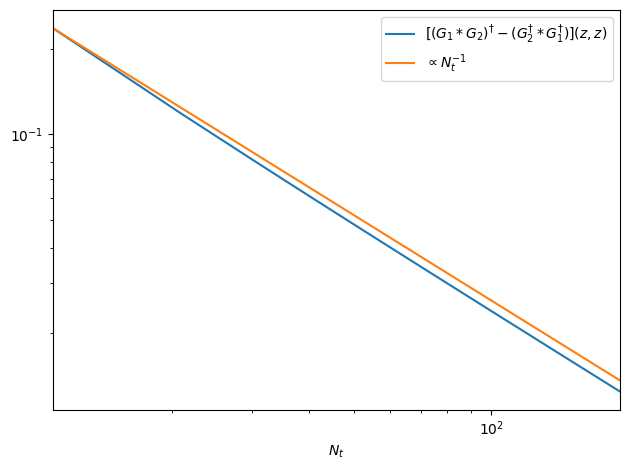

In [5]:
N_t_list = np.array(N_t_range, dtype=float)

plt.loglog(N_t_list, delta_list, label=r"$[(G_1 * G_2)^\dag - (G_2^\dag * G_1^\dag)](z, z)$")
plt.loglog(N_t_list, delta_list[0] / (N_t_list ** (-1))[0] * N_t_list ** (-1), label="$\propto N_t^{-1}$")
plt.xlim(N_t_list[0], N_t_list[-1])
plt.xlabel(r"$N_t$")
plt.legend()
plt.tight_layout()